# Fast Orbit Characterization

Orbit integration can be expensive when you only need basic orbital parameters
like eccentricity, pericenter, apocenter, or maximum height above the plane.
The Staeckel approximation provides a fast alternative that avoids integration
entirely.

In [1]:
%matplotlib inline
import numpy
from galpy.orbit import Orbit
from galpy.potential import MWPotential2014
from galpy.actionAngle import estimateDeltaStaeckel

## Staeckel approximation for a single orbit

Use `analytic=True` with `type='staeckel'` to compute orbital parameters
without integrating. The Staeckel focal length `delta` is estimated
automatically.

In [2]:
o = Orbit([1.0, 0.1, 1.0, 0.0, 0.1, 0.0])

e_staeckel = o.e(analytic=True, pot=MWPotential2014, type="staeckel")
rap_staeckel = o.rap(analytic=True, pot=MWPotential2014, type="staeckel")
rperi_staeckel = o.rperi(analytic=True, pot=MWPotential2014, type="staeckel")
zmax_staeckel = o.zmax(analytic=True, pot=MWPotential2014, type="staeckel")

print(f"Eccentricity: {e_staeckel:.4f}")
print(f"Apocenter:    {rap_staeckel:.4f}")
print(f"Pericenter:   {rperi_staeckel:.4f}")
print(f"zmax:         {zmax_staeckel:.4f}")

Eccentricity: 0.0749
Apocenter:    1.0845
Pericenter:   0.9333
zmax:         0.0431


## Multiple orbits at once

The Staeckel approximation works efficiently for arrays of orbits.

In [3]:
numpy.random.seed(42)
N = 1000
vxvvs = numpy.column_stack(
    [
        numpy.random.uniform(0.5, 1.5, N),
        numpy.random.normal(0.0, 0.1, N),
        numpy.random.uniform(0.8, 1.2, N),
        numpy.random.normal(0.0, 0.1, N),
        numpy.random.normal(0.0, 0.1, N),
        numpy.random.uniform(0.0, 2 * numpy.pi, N),
    ]
)
os = Orbit(vxvvs)
eccs = os.e(analytic=True, pot=MWPotential2014, type="staeckel")
print(f"Computed {len(eccs)} eccentricities")
print(f"Mean eccentricity: {numpy.mean(eccs):.4f}")
print(f"Std eccentricity:  {numpy.std(eccs):.4f}")

Computed 1000 eccentricities
Mean eccentricity: 0.1338
Std eccentricity:  0.0635


## Estimating the Staeckel focal length

The `estimateDeltaStaeckel` function computes the optimal focal
length `delta` for a given position in a potential. This is done
automatically by the orbit methods, but you can also call it directly.

In [4]:
# For a single position
delta = estimateDeltaStaeckel(MWPotential2014, 1.0, 0.1)
print(f"Estimated delta: {delta:.4f}")

# For an array of positions
Rs = numpy.random.uniform(0.5, 1.5, 100)
zs = numpy.random.normal(0.0, 0.1, 100)
deltas = estimateDeltaStaeckel(MWPotential2014, Rs, zs)
print(f"Mean delta: {numpy.mean(deltas):.4f}")

Estimated delta: 0.4033
Mean delta: 0.4502


## Using actionAngleStaeckelGrid for even faster evaluation

For repeated evaluations at many positions, `actionAngleStaeckelGrid`
builds an interpolation grid that makes subsequent calls very fast.

In [5]:
from galpy.actionAngle import actionAngleStaeckelGrid

# Build the grid (this takes a few seconds)
delta_grid = 0.4
aasg = actionAngleStaeckelGrid(
    pot=MWPotential2014, delta=delta_grid, nE=51, npsi=51, nLz=61
)
print("Grid constructed.")

Grid constructed.


In [6]:
# Evaluate actions for a single orbit
jr, lz, jz = aasg(1.0, 0.1, 1.0, 0.0, 0.1)
print(f"Jr = {jr:.4f}, Lz = {lz:.4f}, Jz = {jz:.4f}")

Jr = 0.0038, Lz = 1.0000, Jz = 0.0020


## Comparison: numerical vs. Staeckel

Let's compare orbital parameters computed by orbit integration vs.
the Staeckel approximation.

  0%|          | 0/50 [00:00<?, ?it/s]

  2%|▏         | 1/50 [00:00<00:08,  5.97it/s]

 74%|███████▍  | 37/50 [00:00<00:00, 168.11it/s]

 80%|████████  | 40/50 [00:00<00:00, 321.71it/s]

 82%|████████▏ | 41/50 [00:00<00:00, 321.71it/s]

 84%|████████▍ | 42/50 [00:00<00:00, 321.71it/s]

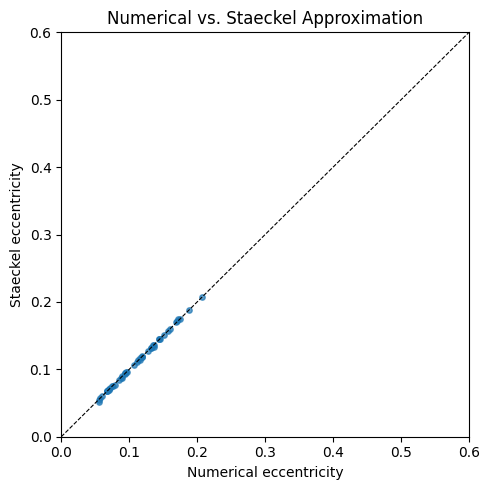

In [7]:
import matplotlib.pyplot as plt

numpy.random.seed(123)
N_cmp = 50
vxvvs_cmp = numpy.column_stack(
    [
        numpy.random.uniform(0.6, 1.4, N_cmp),
        numpy.random.normal(0.0, 0.08, N_cmp),
        numpy.random.uniform(0.85, 1.15, N_cmp),
        numpy.random.normal(0.0, 0.08, N_cmp),
        numpy.random.normal(0.0, 0.08, N_cmp),
        numpy.random.uniform(0.0, 2 * numpy.pi, N_cmp),
    ]
)
os_cmp = Orbit(vxvvs_cmp)

# Numerical: integrate then compute
ts = numpy.linspace(0.0, 50.0, 50000)
os_cmp.integrate(ts, MWPotential2014)
e_num = os_cmp.e()

# Staeckel: no integration needed, but we can use the same object
e_ana = os_cmp.e(analytic=True, pot=MWPotential2014, type="staeckel")

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], "k--", lw=0.8)
ax.scatter(e_num, e_ana, s=15, alpha=0.7)
ax.set_xlabel("Numerical eccentricity")
ax.set_ylabel("Staeckel eccentricity")
ax.set_title("Numerical vs. Staeckel Approximation")
ax.set_xlim(0, 0.6)
ax.set_ylim(0, 0.6)
plt.tight_layout()